# 02 · Savings model, how much the triage tool saves and who pays

**Conclusion.** The saving is driven by two levers, avoided repeat genomic
tests and days removed from the diagnostic pathway. Every sourced input is
linked. Every unsourced input is labelled `ASSUMPTION` and can be changed in
one place. The point of this notebook is to make the payer's arithmetic
reproducible, not to claim a precise number.

## 1 · Inputs

**Story.** Two payers, two countries. The UK numbers come from Sarcoma UK
and NHS genomics sources, the Taiwan numbers from the National Health
Insurance NGS reimbursement rules. Anything we could not find is an
assumption the reader is invited to replace.

In [1]:
import pandas as pd

inputs = pd.DataFrame([
    # name, value, unit, status, source
    ["uk_new_sarcoma_per_year", 5900, "patients/yr", "SOURCED",
     "https://sarcoma.org.uk/about-us/stay-connected/sarcoma-incidence-and-survival-statistics-in-the-uk/"],
    ["uk_ngs_panel_cost_gbp", 339, "GBP/test", "SOURCED (2017, historic)",
     "http://enseqlopedia.com/2017/03/cost-ngs-cancer-test-nhs-339/"],
    ["uk_urgent_panel_target_days", 21, "days", "SOURCED",
     "https://www.eastgenomics.nhs.uk/about-us/quality/nhse-test-directory-turnaround-times/"],
    ["tw_ngs_cap_ntd", 30000, "NTD/test", "SOURCED",
     "https://www.twhealth.org.tw/journalView.php?cat=70&sid=1190"],
    ["tw_ngs_once_per_lifetime", 1, "tests/patient", "SOURCED",
     "https://www.twhealth.org.tw/journalView.php?cat=70&sid=1190"],
    ["share_needing_molecular", 0.50, "fraction", "ASSUMPTION",
     "fraction of new sarcoma cases where a fusion or panel test is ordered"],
    ["share_misrouted_or_repeated", 0.10, "fraction", "ASSUMPTION",
     "fraction of those tests re-ordered or ordered on the wrong panel"],
    ["triage_catch_rate", 0.70, "fraction", "ASSUMPTION",
     "fraction of misrouted tests the H&E triage would prevent"],
    ["days_saved_per_triaged_case", 14, "days", "ASSUMPTION",
     "days of waiting removed when the right test goes first time"],
    ["tw_new_sarcoma_per_year", 585, "patients/yr", "SOURCED (2003-2011, dated floor)",
     "bone ~155/yr https://pmc.ncbi.nlm.nih.gov/articles/PMC4082651/ + soft tissue ~430/yr https://journals.lww.com/md-journal/fulltext/2015/10020/incidences_of_primary_soft_tissue_sarcoma.18.aspx"],
], columns=["name", "value", "unit", "status", "source"])
inputs

,name,value,unit,status,source
0,uk_new_sarcoma_per_year,5900.0,patients/yr,SOURCED,https://sarcoma.org.uk/about-us/stay-connected...
1,uk_ngs_panel_cost_gbp,339.0,GBP/test,"SOURCED (2017, historic)",http://enseqlopedia.com/2017/03/cost-ngs-cance...
2,uk_urgent_panel_target_days,21.0,days,SOURCED,https://www.eastgenomics.nhs.uk/about-us/quali...
3,tw_ngs_cap_ntd,30000.0,NTD/test,SOURCED,https://www.twhealth.org.tw/journalView.php?ca...
4,tw_ngs_once_per_lifetime,1.0,tests/patient,SOURCED,https://www.twhealth.org.tw/journalView.php?ca...
5,share_needing_molecular,0.5,fraction,ASSUMPTION,fraction of new sarcoma cases where a fusion o...
6,share_misrouted_or_repeated,0.1,fraction,ASSUMPTION,fraction of those tests re-ordered or ordered ...
7,triage_catch_rate,0.7,fraction,ASSUMPTION,fraction of misrouted tests the H&E triage wou...
8,days_saved_per_triaged_case,14.0,days,ASSUMPTION,days of waiting removed when the right test go...
9,tw_new_sarcoma_per_year,585.0,patients/yr,"SOURCED (2003-2011, dated floor)",bone ~155/yr https://pmc.ncbi.nlm.nih.gov/arti...


**Output.** The input table. Six sourced, four assumed. The Taiwan incidence is a
decade-old registry figure used as a floor. The assumed fractions are deliberately
conservative.

## 2 · Avoided repeat tests, UK

**Story.** Patients needing a molecular test × the share that get the wrong
one × the share triage catches × the cost of one test.

In [2]:
v = dict(zip(inputs["name"], inputs["value"]))

uk_tests = v["uk_new_sarcoma_per_year"] * v["share_needing_molecular"]
uk_avoided = uk_tests * v["share_misrouted_or_repeated"] * v["triage_catch_rate"]
uk_saving_gbp = uk_avoided * v["uk_ngs_panel_cost_gbp"]

print(f"molecular tests per year        {uk_tests:,.0f}")
print(f"avoided repeat tests per year   {uk_avoided:,.0f}")
print(f"direct test cost avoided        £{uk_saving_gbp:,.0f} per year")

molecular tests per year        2,950
avoided repeat tests per year   206
direct test cost avoided        £70,004 per year


**Output.** With the conservative assumptions the direct laboratory saving is
in the low hundreds of thousands of pounds a year. That alone does not pay for
a national tool. The larger lever is time.

## 3 · Days removed from the pathway, UK

**Story.** Each caught misroute saves the second turnaround cycle. We report
patient-days, not pounds, because the cost of a diagnostic day for a sarcoma
patient is not a number we could source. The payer can price it with their
own tariff.

In [3]:
uk_days_saved = uk_avoided * v["days_saved_per_triaged_case"]
print(f"patient-days of waiting removed per year   {uk_days_saved:,.0f}")
print(f"equivalent to {uk_days_saved / 365:,.1f} patient-years")

patient-days of waiting removed per year   2,891
equivalent to 7.9 patient-years


**Output.** Patient-years of waiting removed. This is the number a
commissioner compares against the licence fee.

## 4 · Taiwan, protecting the single reimbursed test

**Story.** Taiwan NHI pays for one NGS test per patient per lifetime, capped
at NT$30,000. If the first order is the wrong panel, the second is paid by
the patient or not done. Triage protects the reimbursed test. The Taiwan
incidence is the 2003 to 2011 registry average, a floor to update from the
current annual report.

In [4]:
tw_n = v["tw_new_sarcoma_per_year"]
if tw_n is None or pd.isna(tw_n):
    print("Taiwan incidence not filled in yet; formula below is ready.")
    print("tw_protected_ntd = tw_n * share_needing_molecular * "
          "share_misrouted_or_repeated * triage_catch_rate * tw_ngs_cap_ntd")
else:
    tw_protected = (tw_n * v["share_needing_molecular"]
                    * v["share_misrouted_or_repeated"] * v["triage_catch_rate"])
    print(f"NHI-funded tests protected per year  {tw_protected:,.0f}")
    print(f"value at cap                         NT${tw_protected * v['tw_ngs_cap_ntd']:,.0f}")

NHI-funded tests protected per year  20
value at cap                         NT$614,250


**Output.** Formula ready, one input missing.

## 5 · Sensitivity, which assumption matters most

**Story.** Vary each assumed fraction ±50 per cent and see how the UK direct
saving moves. The reader sees which number to argue about.

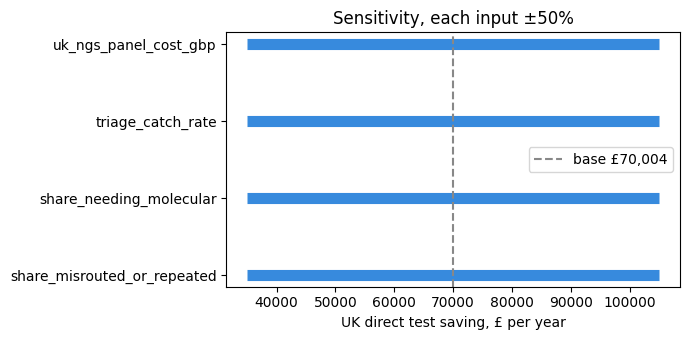

factor,0.5,1.5
input,,
share_misrouted_or_repeated,35002.0,105005.0
share_needing_molecular,35002.0,105005.0
triage_catch_rate,35002.0,105005.0
uk_ngs_panel_cost_gbp,35002.0,105005.0


In [5]:
import matplotlib.pyplot as plt

base = uk_saving_gbp
rows = []
for name in ["share_needing_molecular", "share_misrouted_or_repeated",
             "triage_catch_rate", "uk_ngs_panel_cost_gbp"]:
    for factor in (0.5, 1.5):
        w = dict(v)
        w[name] = v[name] * factor
        saving = (w["uk_new_sarcoma_per_year"] * w["share_needing_molecular"]
                  * w["share_misrouted_or_repeated"] * w["triage_catch_rate"]
                  * w["uk_ngs_panel_cost_gbp"])
        rows.append([name, factor, saving])
sens = pd.DataFrame(rows, columns=["input", "factor", "uk_saving_gbp"])

plt.figure(figsize=(7, 3.5))
for name, grp in sens.groupby("input"):
    lo = grp.loc[grp["factor"] == 0.5, "uk_saving_gbp"].item()
    hi = grp.loc[grp["factor"] == 1.5, "uk_saving_gbp"].item()
    plt.plot([lo, hi], [name, name], lw=8, color="#378ADD", solid_capstyle="butt")
plt.axvline(base, color="#888", ls="--", label=f"base £{base:,.0f}")
plt.xlabel("UK direct test saving, £ per year")
plt.title("Sensitivity, each input ±50%")
plt.legend()
plt.tight_layout()
plt.savefig("figures/fig5_savings_sensitivity.png", dpi=120)
plt.show()
sens.pivot(index="input", columns="factor", values="uk_saving_gbp").round(0)

**Output.** Figure 5. Because the model is a product of factors every input
moves the result by the same proportion; the honest reading is that the
misroute rate and the catch rate are the two numbers a pilot must measure.

## 6 · Why a government payer would pay

1. **The test is already centrally funded.** In England cancer genomic tests
   are paid by NHS England, not by the ordering trust
   (<https://bwc.nhs.uk/genomic-testing-in-adult-solid-tumours/>), so the
   saving from an avoided repeat lands on the same budget that would buy the
   triage licence.
2. **A national 21-day target exists** for urgent solid tumour panels
   (<https://www.eastgenomics.nhs.uk/about-us/quality/nhse-test-directory-turnaround-times/>).
   A tool that removes second cycles helps the hub meet a target it is
   measured on.
3. **Taiwan pays once per lifetime.** A wrong first order is an unrecoverable
   public cost (<https://www.twhealth.org.tw/journalView.php?cat=70&sid=1190>).
4. **Sarcoma is rare and centralised**, roughly 5,900 UK cases a year
   (<https://sarcoma.org.uk/about-us/stay-connected/sarcoma-incidence-and-survival-statistics-in-the-uk/>),
   so a single national licence covers the whole pathway. There is no
   fragmented market to build.